In [4]:
# Solar Power Generation Prediction using LSTM
# Deep Learning Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
TensorFlow version: 2.20.0


In [6]:
# Load and explore the dataset
df = pd.read_csv('solarpowergeneration.csv')
print("Dataset loaded successfully!")

# Basic information about the dataset
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully!
Dataset shape: (4213, 21)

First 5 rows:
   temperature_2_m_above_gnd  relative_humidity_2_m_above_gnd  \
0                       2.17                               31   
1                       2.31                               27   
2                       3.65                               33   
3                       5.82                               30   
4                       7.73                               27   

   mean_sea_level_pressure_MSL  total_precipitation_sfc  snowfall_amount_sfc  \
0                       1035.0                      0.0                  0.0   
1                       1035.1                      0.0                  0.0   
2                       1035.4                      0.0                  0.0   
3                       1035.4                      0.0                  0.0   
4                       1034.4                      0.0                  0.0   

   total_cloud_cover_sfc  high_cloud_cover_high_cld_lay  \

In [8]:
# Feature Engineering and Selection

# Select features based on correlation and domain knowledge
selected_features = [
    'temperature_2_m_above_gnd',
    'relative_humidity_2_m_above_gnd',
    'mean_sea_level_pressure_MSL',
    'total_precipitation_sfc',
    'total_cloud_cover_sfc',
    'shortwave_radiation_backwards_sfc',
    'wind_speed_10_m_above_gnd',
    'angle_of_incidence',
    'zenith',
    'azimuth'
]

print("Selected features for modeling:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

# Create feature matrix and target vector
# Verify selected features exist in the dataframe
missing = [f for f in selected_features if f not in df.columns]
if missing: raise KeyError(f"Missing features: {missing}")
# Create feature matrix and target vector
X = df[selected_features].values
y = df['generated_power_kw'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Check for any infinite or NaN values
print(f"\nNaN values in X: {np.isnan(X).sum()}")
print(f"NaN values in y: {np.isnan(y).sum()}")
print(f"Infinite values in X: {np.isinf(X).sum()}")
print(f"Infinite values in y: {np.isinf(y).sum()}")

Selected features for modeling:
1. temperature_2_m_above_gnd
2. relative_humidity_2_m_above_gnd
3. mean_sea_level_pressure_MSL
4. total_precipitation_sfc
5. total_cloud_cover_sfc
6. shortwave_radiation_backwards_sfc
7. wind_speed_10_m_above_gnd
8. angle_of_incidence
9. zenith
10. azimuth

Feature matrix shape: (4213, 10)
Target vector shape: (4213,)

NaN values in X: 0
NaN values in y: 0
Infinite values in X: 0
Infinite values in y: 0


In [9]:
# Data Preprocessing and Scaling

# Handle any NaN values (if any)
X = np.nan_to_num(X)
y = np.nan_to_num(y)

# Scale the features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale the target variable
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print("Data scaling completed!")
print(f"Scaled X shape: {X_scaled.shape}")
print(f"Scaled y shape: {y_scaled.shape}")

# Create sequences for LSTM
def create_sequences(X, y, time_steps=24):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Create sequences
time_steps = 24  # Using 24 previous time steps to predict next value
X_sequences, y_sequences = create_sequences(X_scaled, y_scaled, time_steps)

print(f"\nSequences created with {time_steps} time steps")
print(f"X_sequences shape: {X_sequences.shape}")
print(f"y_sequences shape: {y_sequences.shape}")

Data scaling completed!
Scaled X shape: (4213, 10)
Scaled y shape: (4213,)

Sequences created with 24 time steps
X_sequences shape: (4189, 24, 10)
y_sequences shape: (4189,)


In [10]:
# Train-Test Split

# Split the data (80% train, 20% test)
split_idx = int(0.8 * len(X_sequences))
X_train, X_test = X_sequences[:split_idx], X_sequences[split_idx:]
y_train, y_test = y_sequences[:split_idx], y_sequences[split_idx:]

print(f"Training set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")

# Further split training set for validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\nFinal training set: {X_train_final.shape}, {y_train_final.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set shape: X_train (3351, 24, 10), y_train (3351,)
Testing set shape: X_test (838, 24, 10), y_test (838,)

Final training set: (2680, 24, 10), (2680,)
Validation set: (671, 24, 10), (671,)
Test set: (838, 24, 10), (838,)


In [11]:
# LSTM Model Architecture


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
def create_lstm_model(input_shape):
    model = Sequential()

    # Increase dropout and L2 regularization
    model.add(LSTM(
        units=50,
        return_sequences=True,
        input_shape=input_shape,
        kernel_regularizer=l2(0.01),  # Increased from 0.001
        recurrent_regularizer=l2(0.01),  # Add recurrent regularization
        name='lstm_1'
    ))
    model.add(BatchNormalization(name='bn_1'))
    model.add(Dropout(0.5, name='dropout_1'))  # Increased from 0.3

    model.add(LSTM(
        units=50,
        return_sequences=False,
        kernel_regularizer=l2(0.01),  # Increased from 0.001
        recurrent_regularizer=l2(0.01),  # Add recurrent regularization
        name='lstm_2'
    ))
    model.add(Dropout(0.5, name='dropout_2'))  # Increased from 0.3

    model.add(Dense(units=1, name='output'))

    return model




# Create model
input_shape = (X_train_final.shape[1], X_train_final.shape[2])
model = create_lstm_model(input_shape)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("LSTM Model created successfully!")
print(model.summary())

LSTM Model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 50)         │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 24, 50)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,651 (127.54 KB)

 Trainable params: 32,551 (127.15 KB)

 Non-trainable params: 100 (400.00 B)

None


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,  # Stop if no improvement for 15 epochs
    restore_best_weights=True,
    verbose=1
)

# Learning rate scheduler (you already have this)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train with callbacks
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.1789 - mae: 0.6136 - val_loss: 1.7585 - val_mae: 0.6625 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.4043 - mae: 0.5096 - val_loss: 1.2262 - val_mae: 0.5723 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0388 - mae: 0.4681 - val_loss: 0.9272 - val_mae: 0.4987 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8416 - mae: 0.4490 - val_loss: 0.7498 - val_mae: 0.4488 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7146 - mae: 0.4409 - val_loss: 0.6326 - val_mae: 0.4027 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6190 - mae: 0.4287 - val_loss: 0.5610 - val_mae: 0.3788 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5601 - mae: 0.4253 - val_loss: 0.5067 - val_mae: 0.3736 - learning_rate: 0.0010
Epoch 

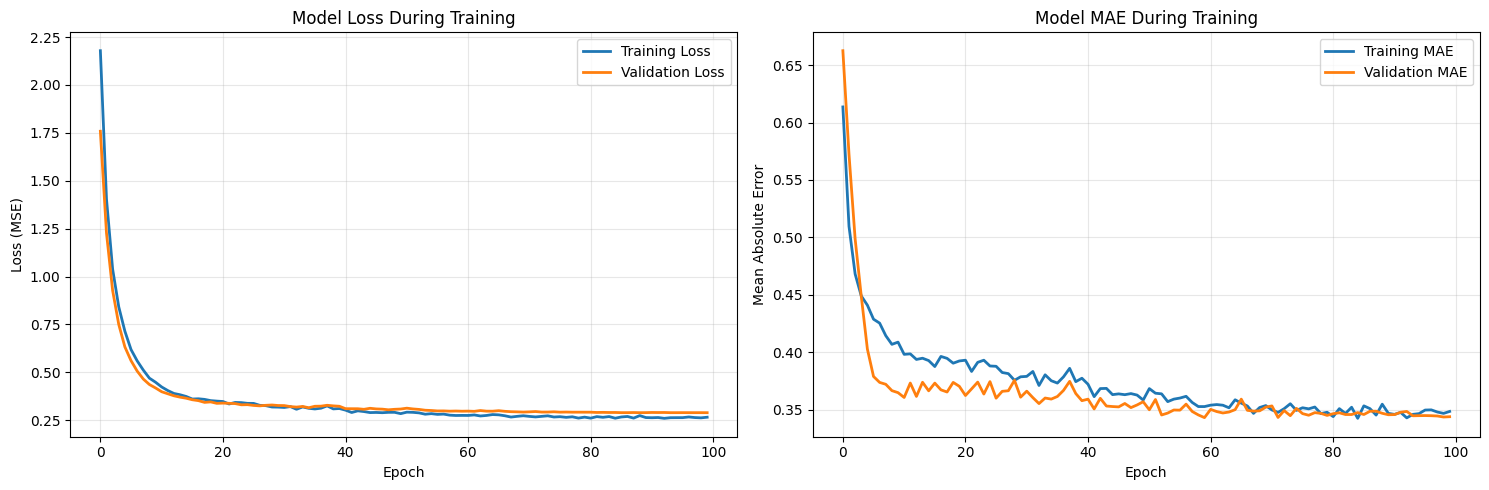

Final Training Loss (MSE): 0.2656
Final Validation Loss (MSE): 0.2892
Final Training MAE: 0.3483
Final Validation MAE: 0.3437


In [13]:
# Training History Visualization

plt.figure(figsize=(15, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training & validation MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('Model MAE During Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final training metrics
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_mae = history.history['mae'][-1]
final_val_mae = history.history['val_mae'][-1]

print(f"Final Training Loss (MSE): {final_train_loss:.4f}")
print(f"Final Validation Loss (MSE): {final_val_loss:.4f}")
print(f"Final Training MAE: {final_train_mae:.4f}")
print(f"Final Validation MAE: {final_val_mae:.4f}")

In [14]:
# Model Evaluation

# Make predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Calculate metrics
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Calculate additional metrics
mape = np.mean(np.abs((y_test_actual - y_pred) / (y_test_actual + 1e-8))) * 100
explained_variance = 1 - (np.var(y_test_actual - y_pred) / np.var(y_test_actual))

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Explained Variance Score: {explained_variance:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Model Evaluation Metrics:
Mean Squared Error (MSE): 369882.3907
Root Mean Squared Error (RMSE): 608.1796
Mean Absolute Error (MAE): 475.9768
R² Score: 0.5524
Mean Absolute Percentage Error (MAPE): 12679.31%
Explained Variance Score: 0.6039


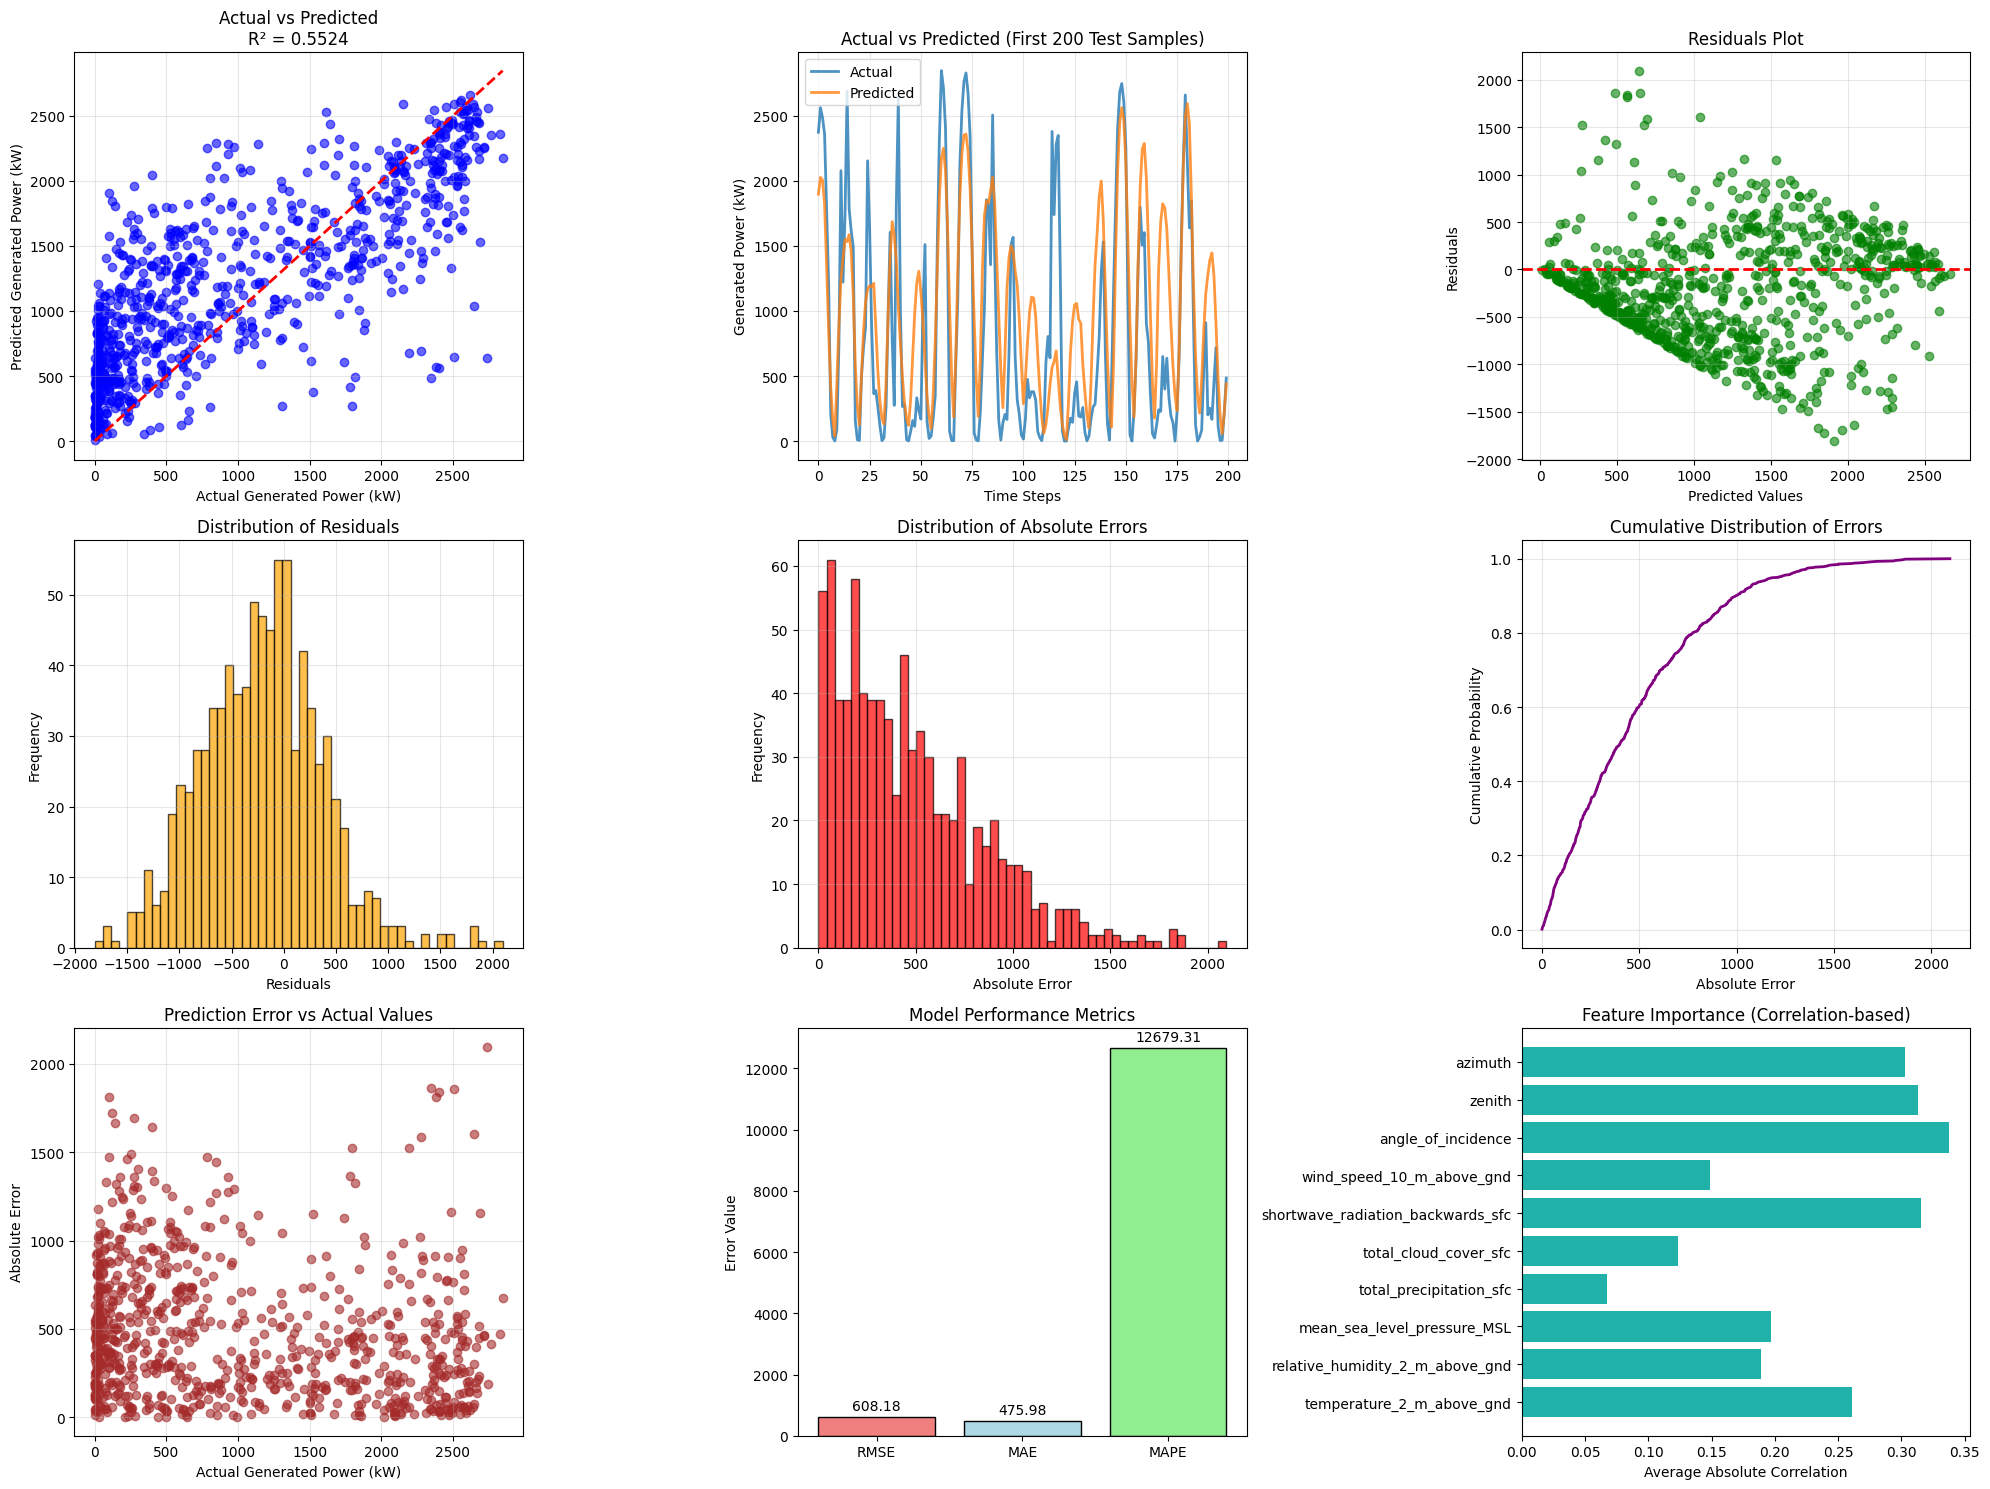

In [15]:
# Results Visualization

plt.figure(figsize=(20, 15))

# 1. Actual vs Predicted values scatter plot
plt.subplot(3, 3, 1)
plt.scatter(y_test_actual, y_pred, alpha=0.6, color='blue')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--', linewidth=2)
plt.xlabel('Actual Generated Power (kW)')
plt.ylabel('Predicted Generated Power (kW)')
plt.title(f'Actual vs Predicted\nR² = {r2:.4f}')
plt.grid(True, alpha=0.3)

# 2. Time series comparison (first 200 test samples)
plt.subplot(3, 3, 2)
plt.plot(y_test_actual[:200], label='Actual', linewidth=2, alpha=0.8)
plt.plot(y_pred[:200], label='Predicted', linewidth=2, alpha=0.8)
plt.xlabel('Time Steps')
plt.ylabel('Generated Power (kW)')
plt.title('Actual vs Predicted (First 200 Test Samples)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Residuals plot
plt.subplot(3, 3, 3)
residuals = y_test_actual - y_pred
plt.scatter(y_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid(True, alpha=0.3)

# 4. Distribution of residuals
plt.subplot(3, 3, 4)
plt.hist(residuals, bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

# 5. Error distribution
plt.subplot(3, 3, 5)
errors = np.abs(y_test_actual - y_pred)
plt.hist(errors, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.grid(True, alpha=0.3)

# 6. Cumulative distribution of errors
plt.subplot(3, 3, 6)
sorted_errors = np.sort(errors)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
plt.plot(sorted_errors, cdf, linewidth=2, color='purple')
plt.xlabel('Absolute Error')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution of Errors')
plt.grid(True, alpha=0.3)

# 7. Prediction error vs actual values
plt.subplot(3, 3, 7)
plt.scatter(y_test_actual, errors, alpha=0.6, color='brown')
plt.xlabel('Actual Generated Power (kW)')
plt.ylabel('Absolute Error')
plt.title('Prediction Error vs Actual Values')
plt.grid(True, alpha=0.3)

# 8. Metrics comparison
plt.subplot(3, 3, 8)
metrics = ['RMSE', 'MAE', 'MAPE']
values = [rmse, mae, mape]
colors = ['lightcoral', 'lightblue', 'lightgreen']
bars = plt.bar(metrics, values, color=colors, edgecolor='black')
plt.ylabel('Error Value')
plt.title('Model Performance Metrics')
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
             f'{value:.2f}', ha='center', va='bottom')

# 9. Feature importance from model (using permutation importance approximation)
plt.subplot(3, 3, 9)
# Since we can't easily get feature importance from LSTM, we'll use correlation
feature_importance = np.abs(np.corrcoef(X_test.reshape(X_test.shape[0], -1).T,
                                      y_test_actual)[:-1, -1])
feature_names_extended = [f'{feat}_t-{i}' for i in range(time_steps, 0, -1)
                        for feat in selected_features]
# Take average importance for each original feature
avg_importance = []
for i in range(len(selected_features)):
    idx = list(range(i, len(feature_importance), len(selected_features)))
    avg_importance.append(np.mean(feature_importance[idx]))

plt.barh(selected_features, avg_importance, color='lightseagreen')
plt.xlabel('Average Absolute Correlation')
plt.title('Feature Importance (Correlation-based)')
plt.tight_layout()

plt.show()

In [17]:
# Simple Solar Power Prediction - Minimal Input

print("=" * 60)
print("🌞 SOLAR POWER GENERATION PREDICTOR")
print("=" * 60)
print("\nEnter the following details:\n")

try:
    # Take only 4-5 most important inputs
    print("☀️  Solar Radiation (W/m²) - How strong is the sunlight?")
    radiation = float(input("   [Example: 800]: "))

    print("\n🌡️  Temperature (°C) - Current temperature")
    temp = float(input("   [Example: 25]: "))

    print("\n☁️  Cloud Cover (%) - How cloudy is it?")
    cloud_cover = float(input("   [Example: 20]: "))

    print("\n💨 Wind Speed (m/s) - How windy is it?")
    wind_speed = float(input("   [Example: 3.5]: "))

    print("\n💧 Humidity (%) - Moisture in air")
    humidity = float(input("   [Example: 60]: "))

    # Set default values for other parameters
    pressure = 1013.25  # Standard atmospheric pressure
    precipitation = 0.0  # Assume no rain
    angle_incidence = 30.0  # Typical solar panel angle
    zenith = 45.0  # Mid-day sun position
    azimuth = 180.0  # South-facing panels

    print("\n⏳ Calculating...")

    # Create input array (24 time steps)
    input_data = np.array([
        [temp] * 24,
        [humidity] * 24,
        [pressure] * 24,
        [precipitation] * 24,
        [cloud_cover] * 24,
        [radiation] * 24,
        [wind_speed] * 24,
        [angle_incidence] * 24,
        [zenith] * 24,
        [azimuth] * 24
    ]).T

    # Scale and predict
    input_scaled = scaler_X.transform(input_data)
    input_sequence = input_scaled.reshape(1, 24, 10)
    prediction_scaled = model.predict(input_sequence, verbose=0)
    predicted_power = scaler_y.inverse_transform(prediction_scaled)[0][0]

    # Show result
    print("\n" + "=" * 60)
    print("✅ RESULT")
    print("=" * 60)
    print(f"\n⚡ PREDICTED SOLAR POWER: {predicted_power:.2f} kW")
    print(f"\n💡 This means your solar panels will generate")
    print(f"   approximately {predicted_power:.2f} kilowatts of electricity")

    # Additional insights
    if predicted_power > 5:
        print("\n🌟 Excellent! Great conditions for solar power generation!")
    elif predicted_power > 3:
        print("\n😊 Good solar power generation expected!")
    elif predicted_power > 1:
        print("\n☁️ Moderate solar power generation.")
    else:
        print("\n🌙 Low solar power generation (poor conditions).")

    print("=" * 60)

except ValueError:
    print("\n❌ Please enter valid numbers!")
except Exception as e:
    print(f"\n❌ Error: {e}")


🌞 SOLAR POWER GENERATION PREDICTOR

Enter the following details:

☀️  Solar Radiation (W/m²) - How strong is the sunlight?

🌡️  Temperature (°C) - Current temperature

☁️  Cloud Cover (%) - How cloudy is it?

💨 Wind Speed (m/s) - How windy is it?

💧 Humidity (%) - Moisture in air

⏳ Calculating...

✅ RESULT

⚡ PREDICTED SOLAR POWER: 2389.12 kW

💡 This means your solar panels will generate
   approximately 2389.12 kilowatts of electricity

🌟 Excellent! Great conditions for solar power generation!
